# Pose 키포인트 기반 운동 횟수 카운터 — 노이즈와 스무딩 분석

본 과제는 **YOLO Pose로 키포인트를 직접 추출하는 실전 단계**와, **정답이 보장된 합성 데이터로 노이즈·스무딩을 분석하는 단계**를 모두 포함한다. 즉 YOLO를 한 번 직접 돌려 키포인트가 어떻게 나오는지 체험하되, 정밀한 정확도 실험은 라벨이 정확한 합성 데이터로 수행한다. (YOLO 출력에만 의존하지 않는 정직한 설계)

**과제 주제:** YOLO Pose로 추출한 관절 키포인트를 이용해 운동 횟수(reps)를 자동으로 세고,
**키포인트의 노이즈(떨림)가 카운팅 정확도에 어떤 영향을 주는지**, 그리고
**스무딩(이동평균)으로 이를 얼마나 개선할 수 있는지** 실험으로 검증한다.

---

### 연구 질문 (Research Questions)
- **RQ1.** 관절 각도 신호에는 어떤 형태의 노이즈가 존재하는가? (시각화로 확인)
- **RQ2.** 노이즈는 reps 카운팅 정확도를 얼마나 떨어뜨리는가?
- **RQ3.** 이동평균 스무딩은 정확도를 얼마나 개선하는가? 윈도우 크기는 어떻게 골라야 하는가?
- **RQ4.** (미니 실험) 각도 임계값(threshold)은 정확도에 얼마나 민감한가?

### 학습 목표 (비전 공부하는 학생용)
1. Pose estimation 결과(키포인트)를 **feature(관절 각도)** 로 변환하는 과정 이해
2. 실제 비전 신호에 **노이즈가 존재함을 눈으로 확인**하고 원인을 추론
3. **전처리(스무딩)의 효과를 정량 평가**하는 실험 설계 경험
4. **정답(ground truth) 라벨을 만들고 정확도/오차(MAE)로 평가**하는 ML 평가 흐름 습득

### ▶ 실행 순서
1. **섹션 0** — 라이브러리 import & YOLO 모델 로드
2. **섹션 2** — `calc_angle`, `extract_angle_series` 함수 정의 셀 실행
3. **STEP 2-A (섹션 1 위)** — YOLO Pose를 직접 한 번 돌려 키포인트 추출 체험
4. **STEP 2-B (섹션 1)** — 정답이 보장된 합성 키포인트(CSV) 로딩 → `raw_angles` 생성
5. **섹션 3 → 4 → 5 → 6 → 7 → 8** — 노이즈·스무딩 정밀 실험

> 💡 YOLO 체험(2-A)과 정밀 실험(2-B)을 나눈 이유: YOLO는 "직접 돌려보는 경험"을 위해,
> 정밀한 정확도 실험은 "정답이 100% 정확한 합성 데이터"로 하기 위해서다.

> 예상 소요: 약 2시간. 코드를 그냥 돌리지 말고, 각 셀의 **"생각해보기"** 질문에 답하면서 진행하세요.


## 0. 환경 설정

Colab / Kaggle 모두에서 동작합니다. 첫 셀은 라이브러리 설치입니다.
(Kaggle은 인터넷 설정을 켜야 `ultralytics`가 설치됩니다: Settings → Internet On)


In [ ]:
# # 라이브러리 설치
# %pip install -q ultralytics pandas opencv-python
# print("설치 완료")

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

VIDEO_PATH = "squat_test.mp4"
CSV_PATH = "squat_keypoints.csv"
JOINT_TRIPLE = (12, 14, 16)
GROUND_TRUTH_REPS = 8

# pose 전용 모델 로드 (일반 yolov8n.pt가 아니라 -pose 가중치여야 관절을 잡는다)
model = YOLO("yolov8n-pose.pt")
print("모델 로드 완료")

# COCO 17 키포인트 인덱스 참고
# 0:코 1:왼눈 2:오른눈 3:왼귀 4:오른귀
# 5:왼어깨 6:오른어깨 7:왼팔꿈치 8:오른팔꿈치 9:왼손목 10:오른손목
# 11:왼엉덩이 12:오른엉덩이 13:왼무릎 14:오른무릎 15:왼발목 16:오른발목

모델 로드 완료


## 1. 데이터 준비

**이 과제는 제공된 합성 테스트 데이터로 진행합니다.** 정답 횟수가 8회로 정확히 보장되고
키포인트 노이즈가 제어되어 있어, 실험 결과가 깔끔하게 드러나기 때문입니다.

아래 **(A)를 먼저 따라가면** YOLO 설치 없이 바로 실험을 시작할 수 있습니다.
(B)와 (C)는 **과제를 다 끝낸 뒤** 실전 감각을 익히고 싶을 때 도전하는 확장용입니다.

---

### (A) 제공된 합성 테스트 데이터 — 정밀 실험은 여기서 (STEP 2-B) ✅

다음 두 파일을 노트북과 **같은 위치**에 둡니다.
- `squat_test.mp4` : 스쿼트 스틱맨 영상 (정답 **8회**, 360프레임, 키포인트 떨림 포함)
- `squat_keypoints.csv` : 위 영상의 프레임별 키포인트 좌표 (YOLO 없이 바로 각도 계산 가능)

> Colab: 왼쪽 파일 탭에 두 파일을 업로드.
> Kaggle: 우측 **Add Data**로 본인이 올린 데이터셋을 추가하거나, `/kaggle/input/...` 경로 확인.

**다음 할 일:** 아래 셀(섹션 1의 코드 셀)을 실행한 뒤, 곧바로 **섹션 2 → 섹션 3** 순서로 진행하면 됩니다.

---

### (B) 직접 촬영한 영상으로 도전 (과제 후 확장)

스쿼트나 팔굽혀펴기를 **측면에서** 찍은 짧은 mp4를 업로드하고, 섹션 2의 YOLO Pose로 키포인트를 직접 추출합니다.

### (C) 캐글 공개 데이터셋으로 도전 (과제 후 확장)

Kaggle **"Gym Workout/Exercises Video Dataset"** (squats, push-ups 등 운동별 영상 클립).
우측 **Add Data** → `Gym Workout Exercises Video` 검색 → 추가하면 `/kaggle/input/...` 로 접근됩니다.

> ⚠️ (B)·(C)의 실제 영상에는 정답 라벨이 없습니다. 영상을 보고 **실제 횟수를 직접 세어** 적어둬야
> 알고리즘 결과와 비교(정확도 평가)를 할 수 있습니다.

In [2]:
# STEP 2-B: 정밀 실험용 합성 키포인트 로딩 (정답 8회 보장) — 이 셀을 실행하세요.
# CSV에서 키포인트를 읽어 각도 신호(raw_angles)를 만든다. YOLO 설치가 필요 없다.
import pandas as pd

df = pd.read_csv(CSV_PATH)                    # 노트북과 같은 위치에 두기
GROUND_TRUTH_REPS = 8                         # 이 테스트 영상의 정답 횟수
JOINT_TRIPLE = (12, 14, 16)                   # 스쿼트: 오른 엉덩이(12)-무릎(14)-발목(16)
DOWN_THR, UP_THR = 120, 150                   # 제공 CSV 기준 기본 임계값

# ※ 주의: 아래 셀들은 섹션 2의 calc_angle 함수를 사용한다.
#   따라서 [섹션 0 import] → [섹션 2의 calc_angle 정의 셀] 을 먼저 실행한 뒤 이 셀을 실행하면
#   raw_angles 가 채워지고, 바로 섹션 3으로 넘어가 실험을 진행할 수 있다.

def _angle_from_row(row, triple):
    ai, bi, ci = triple
    a = (row[f"kp{ai}_x"], row[f"kp{ai}_y"])
    b = (row[f"kp{bi}_x"], row[f"kp{bi}_y"])
    c = (row[f"kp{ci}_x"], row[f"kp{ci}_y"])
    a, b, c = np.array(a, float), np.array(b, float), np.array(c, float)
    ba, bc = a - b, c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cos, -1.0, 1.0)))

raw_angles = np.array([_angle_from_row(r, JOINT_TRIPLE) for _, r in df.iterrows()])
print("프레임 수:", len(raw_angles), "| 정답 횟수:", GROUND_TRUTH_REPS)
print("각도 범위:", round(raw_angles.min(),1), "~", round(raw_angles.max(),1), "도")

# 합성 테스트 데이터용 임계값 (섹션 5에서 사용): DOWN=120, UP=150

프레임 수: 360 | 정답 횟수: 8
각도 범위: 98.9 ~ 180.0 도


### 🔹 STEP 2-A. YOLO Pose 직접 체험 (모두 수행)

먼저 YOLO Pose를 **직접 한 번 돌려본다.** 제공된 `squat_test.mp4` 또는 본인이 찍은 영상에서
키포인트가 실제로 어떻게 추출되는지 눈으로 확인하는 단계다. (섹션 2의 함수 정의가 필요)

> 목적: "키포인트가 YOLO에서 이렇게 나오는구나"를 체험. 정밀 실험은 다음 STEP에서 합성 데이터로 한다.

#### 스마트폰 영상 전처리 (선택)

스마트폰으로 촬영한 영상은 해상도가 크고 프레임 수가 많아서 YOLO Pose가 느려질 수 있습니다. 아래 셀은 OpenCV만 사용해서 영상을 **리사이즈, FPS 축소, 회전 보정, 최대 프레임 제한** 후 새 mp4 파일로 저장합니다.

- 원본이 크면 `max_side=960` 또는 `720` 정도로 줄이기
- 분석 속도를 높이려면 `target_fps=12~15` 권장
- 세로로 찍혔으면 `rotate_code`를 설정해서 가로로 맞추기
- 전처리 후 `PREPROCESSED_VIDEO_PATH`가 자동으로 YOLO 입력으로 사용됩니다.


In [ ]:
# 스마트폰 영상 전처리 셀 (필요할 때만 실행)
# 예시 파일명: VIDEO_PATH = "my_pushup_phone.mp4"

USE_PREPROCESSED_VIDEO = False   # 스마트폰 영상이면 True로 바꾸고 실행
INPUT_VIDEO_PATH = VIDEO_PATH
OUTPUT_VIDEO_PATH = "processed_" + INPUT_VIDEO_PATH.rsplit('.', 1)[0] + ".mp4"

PREPROCESS_CONFIG = {
    "max_side": 960,      # 긴 변 기준 최대 해상도
    "target_fps": 15,     # 저장할 FPS
    "rotate_code": None,  # 예: cv2.ROTATE_90_CLOCKWISE
    "max_frames": None,   # 예: 900 (너무 긴 영상이면 제한)
}

def preprocess_video_for_pose(input_path, output_path, max_side=960, target_fps=15, rotate_code=None, max_frames=None):
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"비디오를 열 수 없습니다: {input_path}")

    src_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    src_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    src_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    if src_w <= 0 or src_h <= 0:
        cap.release()
        raise ValueError("원본 영상의 해상도를 읽을 수 없습니다.")

    scale = min(1.0, max_side / max(src_w, src_h))
    out_w = max(2, int(round(src_w * scale)))
    out_h = max(2, int(round(src_h * scale)))
    out_w += out_w % 2
    out_h += out_h % 2

    if rotate_code in (cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_90_COUNTERCLOCKWISE):
        writer_size = (out_h, out_w)
    else:
        writer_size = (out_w, out_h)

    target_fps = min(float(target_fps), float(src_fps)) if src_fps > 0 else float(target_fps)
    frame_step = max(1, int(round(src_fps / target_fps))) if target_fps > 0 else 1
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, max(target_fps, 1.0), writer_size)

    frame_idx = 0
    saved = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % frame_step != 0:
            frame_idx += 1
            continue

        if scale != 1.0:
            frame = cv2.resize(frame, (out_w, out_h), interpolation=cv2.INTER_AREA)
        if rotate_code is not None:
            frame = cv2.rotate(frame, rotate_code)
        writer.write(frame)
        saved += 1
        frame_idx += 1
        if max_frames is not None and saved >= max_frames:
            break

    cap.release()
    writer.release()
    return {
        "input_path": input_path,
        "output_path": output_path,
        "src_size": (src_w, src_h),
        "dst_size": writer_size,
        "src_fps": src_fps,
        "dst_fps": max(target_fps, 1.0),
        "saved_frames": saved,
    }

PREPROCESSED_VIDEO_PATH = VIDEO_PATH
if USE_PREPROCESSED_VIDEO:
    info = preprocess_video_for_pose(INPUT_VIDEO_PATH, OUTPUT_VIDEO_PATH, **PREPROCESS_CONFIG)
    PREPROCESSED_VIDEO_PATH = info["output_path"]
    print("전처리 완료")
    print("입력:", info["input_path"], "| 출력:", info["output_path"])
    print("해상도:", info["src_size"], "->", info["dst_size"])
    print("FPS:", round(info["src_fps"], 2), "->", round(info["dst_fps"], 2))
    print("저장 프레임 수:", info["saved_frames"])
else:
    print("전처리 생략: PREPROCESSED_VIDEO_PATH =", PREPROCESSED_VIDEO_PATH)


YOLO로 추출한 프레임 수: 360
각도 범위: 1.1 ~ 180.0 도


/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/sdh08/Pychar

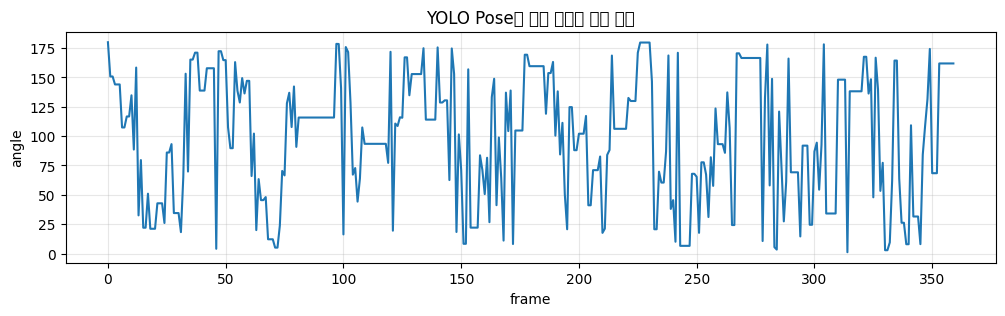

In [3]:
# STEP 2-A: YOLO Pose로 키포인트 추출 체험 (모두 1회 실행)
# 이 셀은 위에서 아래로 바로 실행되도록 독립적으로 동작하게 구성했다.

YOLO_VIDEO = globals().get("PREPROCESSED_VIDEO_PATH", VIDEO_PATH)  # 전처리 셀을 돌렸으면 그 결과 사용

def _calc_angle_local(a, b, c):
    a, b, c = np.array(a, float), np.array(b, float), np.array(c, float)
    ba, bc = a - b, c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cos, -1.0, 1.0)))

def _extract_angle_series_demo(video_path, joint_triple):
    a_idx, b_idx, c_idx = joint_triple
    cap = cv2.VideoCapture(video_path)
    angles = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        res = model(frame, verbose=False)
        kp = res[0].keypoints.xy.cpu().numpy()
        if len(kp) > 0 and kp[0].shape[0] == 17:
            p = kp[0]
            a, b, c = p[a_idx], p[b_idx], p[c_idx]
            if a.sum() > 0 and b.sum() > 0 and c.sum() > 0:
                angles.append(_calc_angle_local(a, b, c))
            else:
                angles.append(angles[-1] if angles else 180.0)
        else:
            angles.append(angles[-1] if angles else 180.0)
    cap.release()
    return np.array(angles)

try:
    yolo_angles = _extract_angle_series_demo(YOLO_VIDEO, JOINT_TRIPLE)
    print("YOLO로 추출한 프레임 수:", len(yolo_angles))
    print("각도 범위:", round(yolo_angles.min(),1), "~", round(yolo_angles.max(),1), "도")
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,3))
    plt.plot(yolo_angles); plt.title("YOLO Pose로 직접 추출한 각도 신호")
    plt.xlabel("frame"); plt.ylabel("angle"); plt.grid(alpha=0.3); plt.show()
except Exception as e:
    print("YOLO 추출 실패(스틱맨 영상은 사람으로 인식 안 될 수 있음):", e)
    print("-> 괜찮습니다. STEP 2-B의 합성 키포인트(CSV)로 정밀 실험을 진행하면 됩니다.")

# 참고: 합성 스틱맨 영상은 YOLO가 사람으로 인식 못 할 수 있다. 그래도 정상이다.
# 본인이 찍은 실제 사람 영상으로 바꾸면 키포인트가 제대로 잡힌다.

## 2. 키포인트 → 관절 각도 (feature 만들기)

reps를 세려면 매 프레임의 "관절 각도"라는 1차원 신호가 필요합니다.
세 점 a, b, c에서 b를 꼭짓점으로 하는 각도를 코사인 법칙으로 구합니다.

**생각해보기:** 왜 키포인트 좌표(x,y)를 그대로 쓰지 않고 *각도*로 바꿀까요?
(힌트: 사람 위치·카메라 거리·키가 달라도 "굽힌 정도"는 각도로 일관되게 표현됩니다 → 불변 feature)


> **(A) 합성 데이터로 진행 중이라면:** 아래 `calc_angle` 셀만 실행하면 됩니다.
> 그 다음 `extract_angle_series` 셀은 실제 영상(B·C)용이므로 **건너뛰고 섹션 3으로** 가세요.
> (이미 섹션 1에서 raw_angles가 만들어져 있습니다.)

In [4]:
def calc_angle(a, b, c):
    """b를 꼭짓점으로 하는 세 점의 각도(도)를 반환. a,b,c는 (x,y)."""
    a, b, c = np.array(a, float), np.array(b, float), np.array(c, float)
    ba, bc = a - b, c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cos, -1.0, 1.0)))

In [5]:
def extract_angle_series(video_path, joint_triple):
    """영상 전체를 돌며 프레임별 관절 각도 리스트를 만든다. (raw 신호)"""
    a_idx, b_idx, c_idx = joint_triple
    cap = cv2.VideoCapture(video_path)
    angles = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        res = model(frame, verbose=False)
        kp = res[0].keypoints.xy.cpu().numpy()  # (사람수, 17, 2)
        if len(kp) > 0 and kp[0].shape[0] == 17:
            p = kp[0]
            a, b, c = p[a_idx], p[b_idx], p[c_idx]
            if a.sum() > 0 and b.sum() > 0 and c.sum() > 0:
                angles.append(calc_angle(a, b, c))
            else:
                angles.append(angles[-1] if angles else 180.0)
        else:
            angles.append(angles[-1] if angles else 180.0)
    cap.release()
    return np.array(angles)

## 3. [RQ1] 노이즈를 눈으로 확인하기

추출한 각도 신호를 그래프로 그려봅니다. 운동을 반복하면 각도가 **오르락내리락 하는 파형**이 나와야 합니다.
하지만 자세히 보면 매끈한 파형이 아니라 **자잘하게 떨리는(노이즈) 부분**이 보입니다.

**생각해보기:** 이 떨림은 왜 생길까요?
- Pose 모델이 프레임마다 키포인트를 약간씩 다르게 추정 (추정 오차)
- 모션 블러, 가려짐(occlusion), 옷·배경의 영향
- 측면이 아닌 각도에서 찍으면 관절이 겹쳐 보임


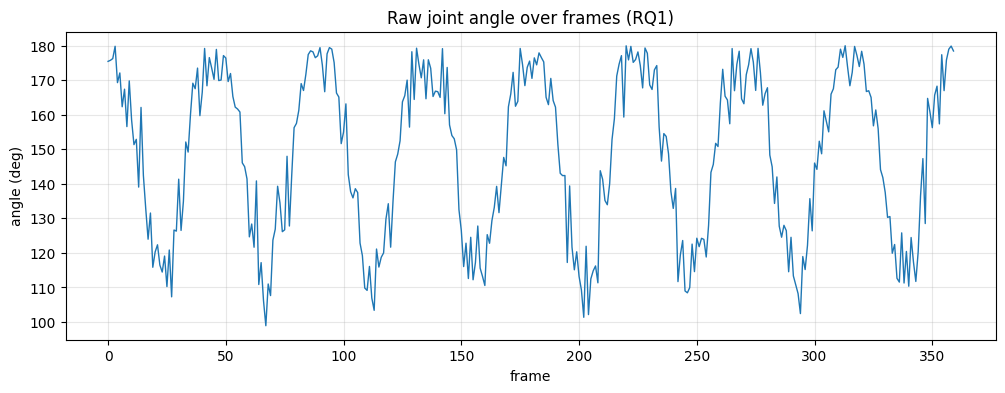

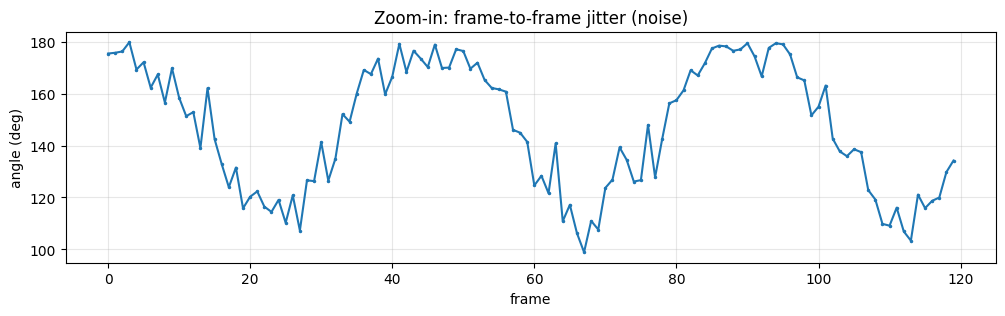

In [6]:
plt.figure(figsize=(12,4))
plt.plot(raw_angles, linewidth=1)
plt.title("Raw joint angle over frames (RQ1)")
plt.xlabel("frame"); plt.ylabel("angle (deg)")
plt.grid(alpha=0.3)
plt.show()

# 떨림을 확대해서 보기: 일부 구간만
plt.figure(figsize=(12,3))
seg = raw_angles[:120]
plt.plot(seg, marker='.', markersize=3)
plt.title("Zoom-in: frame-to-frame jitter (noise)")
plt.xlabel("frame"); plt.ylabel("angle (deg)")
plt.grid(alpha=0.3)
plt.show()

## 4. 스무딩(이동평균) 함수

노이즈를 줄이는 가장 단순한 방법: **이동평균(moving average)**.
연속한 N개 프레임의 각도를 평균내서 신호를 매끄럽게 만듭니다. N이 윈도우 크기입니다.

**생각해보기:** 윈도우가 너무 크면 어떤 부작용이 있을까요?
(힌트: 너무 매끄러워지면 실제 동작의 빠른 변화까지 뭉개져 카운팅을 놓칠 수 있습니다 → 트레이드오프)


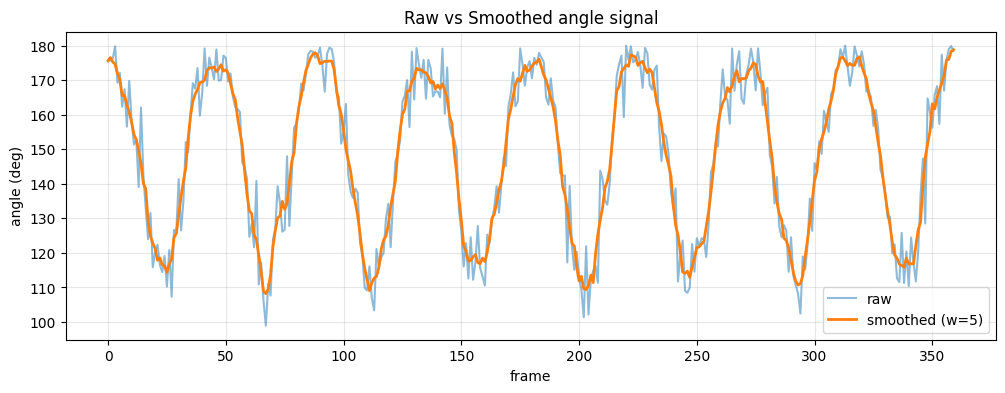

In [7]:
def moving_average(x, window):
    """단순 이동평균. window=1이면 원본 그대로."""
    if window <= 1:
        return x.copy()
    kernel = np.ones(window) / window
    # 'same'으로 길이 유지, 양끝은 edge 패딩으로 처리
    padded = np.pad(x, (window//2, window//2), mode='edge')
    smoothed = np.convolve(padded, kernel, mode='same')
    return smoothed[window//2 : window//2 + len(x)]

# raw vs smoothed 비교 그래프
plt.figure(figsize=(12,4))
plt.plot(raw_angles, alpha=0.5, label="raw")
plt.plot(moving_average(raw_angles, 5), linewidth=2, label="smoothed (w=5)")
plt.title("Raw vs Smoothed angle signal")
plt.xlabel("frame"); plt.ylabel("angle (deg)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 5. 상태머신 기반 reps 카운터

각도 신호로 횟수를 세는 핵심 로직입니다.
각도가 `down_thr` 아래로 내려갔다가(=동작 수행) 다시 `up_thr` 위로 올라오면 1회로 셉니다.

**왜 두 개의 임계값(이력현상, hysteresis)을 쓸까?**
임계값 하나만 쓰면 노이즈가 그 값 근처에서 떨릴 때 1회 동작을 여러 번으로 잘못 셉니다.
아래/위 두 값을 벌려두면 노이즈에 덜 민감해집니다. (이것도 일종의 노이즈 대응 기법!)


In [8]:
def count_reps(angle_series, down_thr, up_thr):
    """각도 신호에서 reps를 센다. 상태(up/down)를 오가며 up 복귀 시 +1."""
    stage = "up"
    count = 0
    for ang in angle_series:
        if ang < down_thr and stage == "up":
            stage = "down"
        if ang > up_thr and stage == "down":
            stage = "up"
            count += 1
    return count

# 스쿼트 기본 임계값 (운동/영상에 맞게 조정 가능)
# 본인 영상(YOLO 사용) 기준 예시: 90, 160
# 제공된 테스트 데이터(squat_keypoints.csv) 기준 기본값: 120, 150
DOWN_THR, UP_THR = 120, 150

raw_count = count_reps(raw_angles, DOWN_THR, UP_THR)
print(f"[raw 신호] 카운트 = {raw_count}  /  정답 = {GROUND_TRUTH_REPS}")

[raw 신호] 카운트 = 8  /  정답 = 8


## 6. [RQ2 & RQ3] 핵심 실험 — 스무딩 윈도우별 정확도 비교

이 과제의 **메인 실험**입니다. 윈도우 크기를 바꿔가며 각각 reps를 세고,
정답과의 오차를 비교합니다.

- **window = 1**: 스무딩 없음 (= raw, RQ2의 노이즈 영향 측정)
- **window ≥ 3**: 스무딩 적용 (RQ3의 개선 효과 측정)

평가 지표: **절대 오차 = |예측 횟수 − 정답 횟수|** (작을수록 좋음)


In [9]:
windows = [1, 3, 5, 7, 9, 11, 15, 21]
results = []
for w in windows:
    sm = moving_average(raw_angles, w)
    cnt = count_reps(sm, DOWN_THR, UP_THR)
    err = abs(cnt - GROUND_TRUTH_REPS)
    results.append((w, cnt, err))

print(f"{'window':>7} | {'predicted':>9} | {'abs_error':>9}")
print("-"*33)
for w, cnt, err in results:
    print(f"{w:>7} | {cnt:>9} | {err:>9}")

 window | predicted | abs_error
---------------------------------
      1 |         8 |         0
      3 |         8 |         0
      5 |         8 |         0
      7 |         8 |         0
      9 |         8 |         0
     11 |         8 |         0
     15 |         4 |         4
     21 |         0 |         8


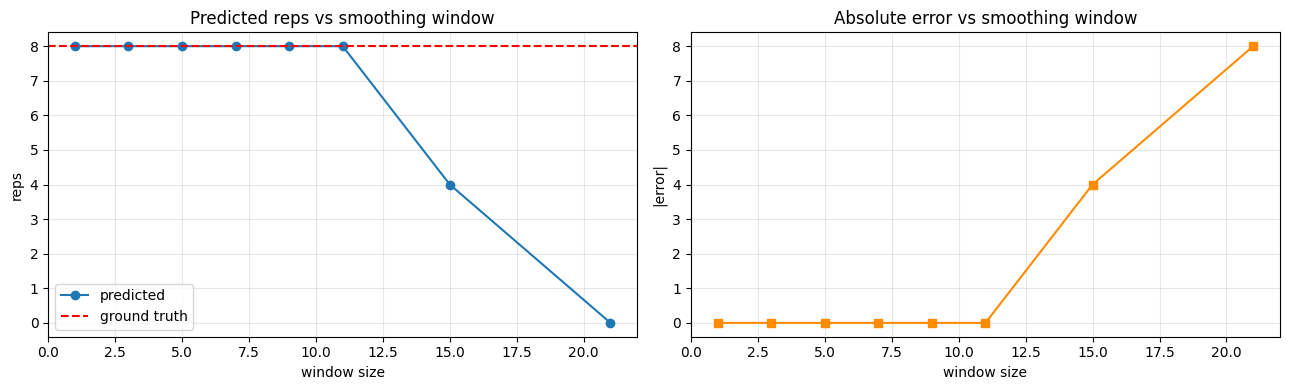

가장 오차가 작은 윈도우: w=1 (예측 8, 오차 0)


In [10]:
ws   = [r[0] for r in results]
cnts = [r[1] for r in results]
errs = [r[2] for r in results]

fig, ax = plt.subplots(1, 2, figsize=(13,4))

ax[0].plot(ws, cnts, marker='o', label="predicted")
ax[0].axhline(GROUND_TRUTH_REPS, color='r', linestyle='--', label="ground truth")
ax[0].set_title("Predicted reps vs smoothing window")
ax[0].set_xlabel("window size"); ax[0].set_ylabel("reps")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ws, errs, marker='s', color='darkorange')
ax[1].set_title("Absolute error vs smoothing window")
ax[1].set_xlabel("window size"); ax[1].set_ylabel("|error|")
ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

best = min(results, key=lambda r: r[2])
print(f"가장 오차가 작은 윈도우: w={best[0]} (예측 {best[1]}, 오차 {best[2]})")

**결과 해석**

이번 실험에서는 `window=1`인 raw 신호에서도 예측 횟수가 정답 `8회`와 같아 절대 오차가 `0`이었다. 즉, 노이즈가 존재하더라도 이번 데이터에서는 기본 임계값이 적절하게 설정되어 있어 raw 상태만으로도 정확한 카운팅이 가능했다.

또한 `window=3, 5, 7, 9, 11`에서도 모두 오차 `0`을 유지했으므로, 약한 수준의 스무딩은 성능을 해치지 않는다는 것을 확인할 수 있었다. 그러나 `window=15`에서는 예측 횟수가 `4회`, `window=21`에서는 `0회`로 줄어들어 오차가 각각 `4`, `8`로 커졌다. 이는 스무딩을 너무 강하게 적용하면 노이즈뿐 아니라 실제 동작 변화까지 함께 평탄화되어 카운터가 스쿼트 동작을 제대로 감지하지 못하게 됨을 보여준다.


## 7. [RQ4] 미니 실험 — 임계값 민감도

스무딩은 best 윈도우로 고정해두고, 이번엔 **down 임계값**을 바꿔가며 정확도를 봅니다.
임계값이 정확도에 얼마나 민감한지 확인하는 실험입니다.


(window=1 고정, up_thr=150 고정)
down_thr | predicted | abs_error
----------------------------------
      70 |         0 |         8
      80 |         0 |         8
      90 |         0 |         8
     100 |         1 |         7
     110 |         6 |         2
     120 |         8 |         0


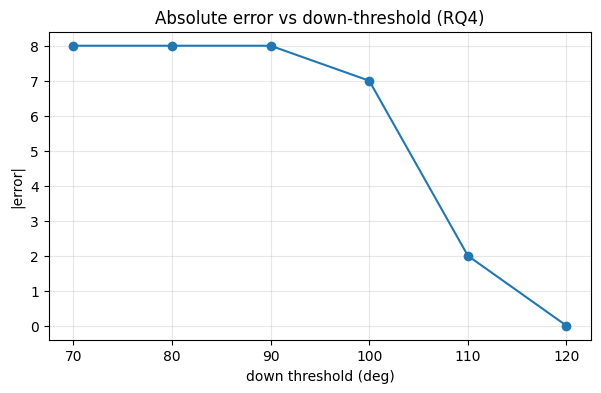

In [11]:
best_w = best[0]
best_smoothed = moving_average(raw_angles, best_w)

down_candidates = [70, 80, 90, 100, 110, 120]
print(f"(window={best_w} 고정, up_thr={UP_THR} 고정)")
print(f"{'down_thr':>8} | {'predicted':>9} | {'abs_error':>9}")
print("-"*34)
th_errs = []
for d in down_candidates:
    cnt = count_reps(best_smoothed, d, UP_THR)
    err = abs(cnt - GROUND_TRUTH_REPS)
    th_errs.append(err)
    print(f"{d:>8} | {cnt:>9} | {err:>9}")

plt.figure(figsize=(7,4))
plt.plot(down_candidates, th_errs, marker='o')
plt.title("Absolute error vs down-threshold (RQ4)")
plt.xlabel("down threshold (deg)"); plt.ylabel("|error|")
plt.grid(alpha=0.3); plt.show()

##  결론



1. **RQ1 — 노이즈 존재**  
각도 신호 그래프를 보면 전체적으로는 스쿼트 동작에 따라 각도가 주기적으로 내려갔다가 올라오는 파형을 보였고, 확대 구간에서는 프레임마다 값이 조금씩 흔들리는 미세한 떨림도 확인할 수 있었다. 이러한 노이즈는 Pose 모델이 매 프레임마다 키포인트를 완전히 동일하게 추정하지 못해 발생하는 추정 오차와 검출 흔들림에서 비롯된 것으로 해석할 수 있다.

2. **RQ2 — 노이즈의 영향**  
이번 실험에서는 스무딩을 적용하지 않은 raw 신호만으로도 예측 횟수가 정답과 같은 `8회`로 계산되었고, 절대 오차는 `0`이었다. 즉 노이즈는 존재했지만, 이번 데이터에서는 그 노이즈가 실제 카운팅 오류로 이어질 정도로 크지는 않았다고 볼 수 있다.

3. **RQ3 — 스무딩 효과**  
스무딩 윈도우를 바꾸어 실험한 결과 `window=1, 3, 5, 7, 9, 11`에서는 모두 예측 횟수 `8회`, 오차 `0`으로 동일한 성능을 보였다. 반면 `window=15`에서는 예측 횟수가 `4회`로 줄어 오차가 `4`가 되었고, `window=21`에서는 예측 횟수가 `0회`로 줄어 오차가 `8`까지 커졌다. 따라서 이번 데이터에서는 작은 윈도우의 스무딩은 성능을 해치지 않았지만, 과도한 스무딩은 실제 동작 변화까지 지나치게 평탄화하여 성능을 악화시켰다.

4. **RQ4 — 임계값 민감도**  
`window=1`을 고정한 상태에서 `down threshold`를 바꾸어 본 결과, `70, 80, 90`에서는 예측 횟수가 `0회`, `100`에서는 `1회`, `110`에서는 `6회`로 나타났고, `120`에서만 정답 `8회`를 정확히 맞췄다. 이 결과를 통해 카운팅 정확도는 임계값 설정에 매우 민감하며, 이번 데이터에서는 `down threshold=120도` 부근이 가장 안정적이라는 것을 확인할 수 있었다.

### 생각해보기 답안

- **왜 키포인트 좌표(x, y)를 그대로 쓰지 않고 각도로 바꾸는가?**  
키포인트 좌표를 그대로 사용하면 사람의 위치, 카메라와의 거리, 신체 크기 차이에 따라 값이 크게 달라질 수 있다. 반면 관절 각도는 사람이 화면 어디에 있든, 얼마나 멀리 있든 비교적 일관되게 "얼마나 굽혔는가"를 표현할 수 있으므로 운동 동작을 더 안정적으로 나타내는 feature라고 볼 수 있다.

- **이 떨림은 왜 생기는가?**  
이 떨림은 Pose 모델이 프레임마다 키포인트를 조금씩 다르게 추정하기 때문에 발생한다. 또한 검출 오차, 프레임 간 미세한 움직임, 가림 현상 등이 겹치면서 각도 값이 완전히 매끄럽지 않게 나타난다.

- **윈도우가 너무 크면 어떤 부작용이 있는가?**  
윈도우가 너무 크면 노이즈뿐 아니라 실제 동작의 빠른 변화까지 함께 평균되어 버린다. 그 결과 각도 신호의 굴곡이 약해지고, 카운터가 임계값을 넘는 순간을 제대로 감지하지 못해 횟수를 적게 세거나 아예 세지 못할 수 있다.

- **왜 두 개의 임계값을 쓰는가?**  
임계값을 하나만 사용하면 신호가 그 값 근처에서 흔들릴 때 한 번의 동작이 여러 번으로 잘못 세어질 수 있다. 반면 `down threshold`와 `up threshold`를 따로 두면 내려간 상태와 다시 올라온 상태를 분리해서 판단할 수 있으므로, 노이즈에 훨씬 덜 민감하고 중복 카운팅을 방지할 수 있다.

### 최종 정리

이번 실험에서는 관절 각도 신호에 프레임 단위의 미세한 노이즈가 존재함을 확인할 수 있었다. 그러나 제공된 테스트 데이터에서는 raw 신호만으로도 정답 `8회`를 정확히 맞췄기 때문에, 노이즈가 항상 카운팅 오류로 이어지는 것은 아니라는 점도 함께 확인되었다. 또한 작은 스무딩 윈도우는 성능을 유지했지만, 너무 큰 윈도우는 실제 동작 변화까지 지나치게 부드럽게 만들어 오히려 횟수를 놓치게 했다. 마지막으로 threshold 실험을 통해 카운팅 성능은 임계값 설정에 매우 민감하며, 이번 데이터에서는 `down=120도`, `up=150도` 부근이 가장 적절하다는 결론을 내릴 수 있었다.

### 한계 & 확장 아이디어 (발표용)
- 영상 1개로만 평가했다 → 여러 영상으로 평균 오차(MAE)를 내면 더 신뢰도 ↑
- 측면 촬영이 아닌 영상에서는 관절이 겹쳐 오차가 커질 것
- 스무딩 대신 칼만 필터, 1€ 필터 등 더 정교한 방법과 비교 가능
- 운동 종류(스쿼트 vs 팔굽혀펴기)별로 같은 실험을 반복해 난이도 비교 가능

### 셀프 체크리스트
- [ ] 각도 신호 그래프를 캡처했다
- [ ] 윈도우별 오차 표/그래프를 만들었다
- [ ] best 윈도우를 찾고 그 이유를 설명할 수 있다
- [ ] 임계값 민감도 실험을 했다
- [ ] 한계점을 1개 이상 적었다
